# Inspect ResMS

GLM residual mean squares (ResMS) per region from the first-level SPM GLMs.
High ResMS relative to the whole-brain mean indicates poor GLM fit quality —
driven by local signal dropout, unmodelled physiological noise, or motion artefacts.

GLM: `glm2_all_runs_scrubbed_2025-12-11-12-44`

Sections:
1. Group mean ResMS spatial map (axial + coronal)
2. Per-subject ROI extraction + summary table
3. Bar chart (normalized to whole-brain mean) + per-subject violin plot


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image, plotting
from nilearn.datasets import fetch_atlas_harvard_oxford

GLM_DIR = "/mnt/data/learning-habits/spm_format/outputs/glm2_all_runs_scrubbed_2025-12-11-12-44"

resms_paths = sorted(glob.glob(os.path.join(GLM_DIR, "sub-*", "ResMS.nii")))
print(f"Found {len(resms_paths)} ResMS files")

PROB_THRESH = 25

ho_cort = fetch_atlas_harvard_oxford('cort-prob-2mm')
ho_sub  = fetch_atlas_harvard_oxford('sub-prob-2mm')
cort_4d = image.load_img(ho_cort.maps)
sub_4d  = image.load_img(ho_sub.maps)


def make_roi(atlas_4d, labels, name_fragments):
    data    = atlas_4d.get_fdata()
    indices = [i for i, l in enumerate(labels)
               if any(f.lower() in l.lower() for f in name_fragments)]
    if not indices:
        raise ValueError(f"No match: {name_fragments}")
    combined = data[..., indices].max(axis=-1)
    return image.new_img_like(atlas_4d, (combined >= PROB_THRESH).astype(np.int8))


rois = {
    "OFC":       make_roi(cort_4d, ho_cort.labels, ["Frontal Orbital Cortex"]),
    "vmPFC":     make_roi(cort_4d, ho_cort.labels, ["Frontal Medial Cortex", "Paracingulate Gyrus"]),
    "ACC":       make_roi(cort_4d, ho_cort.labels, ["Cingulate Gyrus, anterior"]),
    "dlPFC":     make_roi(cort_4d, ho_cort.labels, ["Middle Frontal Gyrus", "Superior Frontal Gyrus"]),
    "Striatum":  make_roi(sub_4d,  ho_sub.labels,  ["Caudate", "Putamen"]),
    "Occipital": make_roi(cort_4d, ho_cort.labels, ["Lateral Occipital"]),
}

PFC_ROIS = ["OFC", "vmPFC", "ACC", "dlPFC"]
REF_ROIS = ["Striatum", "Occipital"]
colors   = {"OFC": "#e41a1c", "vmPFC": "#ff7f00", "ACC": "#4daf4a",
            "dlPFC": "#377eb8", "Striatum": "#984ea3", "Occipital": "#a65628"}


Found 60 ResMS files


/home/ubuntu/miniforge3/envs/neuroim/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


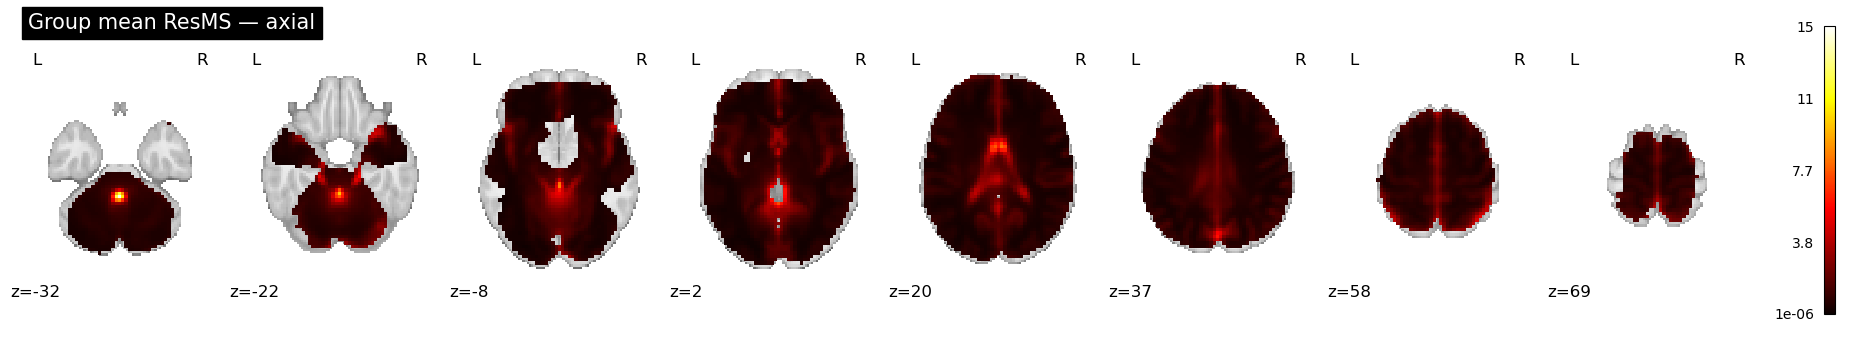

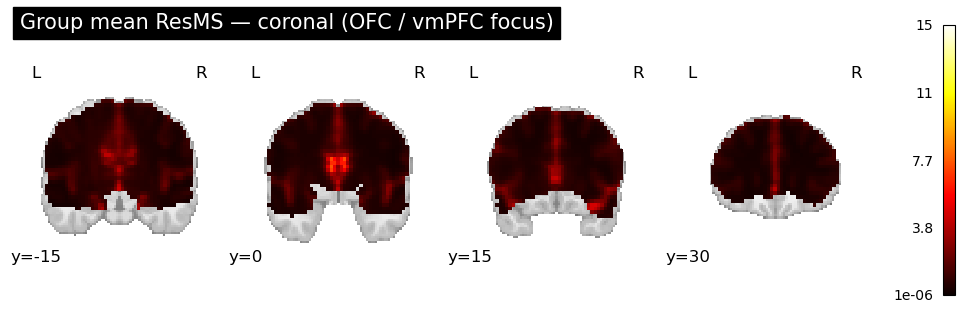

In [2]:
group_resms_img = image.mean_img(resms_paths)

plotting.plot_stat_map(
    group_resms_img,
    display_mode='z', cut_coords=8,
    colorbar=True, cmap='hot',
    title='Group mean ResMS — axial',
    threshold=1e-6,
)
plt.show()

plotting.plot_stat_map(
    group_resms_img,
    display_mode='y', cut_coords=[-15, 0, 15, 30],
    colorbar=True, cmap='hot',
    title='Group mean ResMS — coronal (OFC / vmPFC focus)',
    threshold=1e-6,
)
plt.show()


In [3]:
roi_order = PFC_ROIS + REF_ROIS

records = []
for resms_path in resms_paths:
    subject = resms_path.split('/')[-2]  # e.g. sub-01
    resms_img  = nib.load(resms_path)
    resms_data = resms_img.get_fdata(dtype=np.float32)

    # Resample each ROI to ResMS space and extract mean
    wb_mask = resms_data > 0
    wb_mean = resms_data[wb_mask].mean()

    for roi_name, roi_img in rois.items():
        roi_res  = image.resample_to_img(roi_img, resms_img, interpolation='nearest')
        roi_mask = (roi_res.get_fdata() > 0) & wb_mask
        if roi_mask.sum() == 0:
            continue
        records.append(dict(subject=subject, roi=roi_name,
                            resms=resms_data[roi_mask].mean(),
                            wb_resms=wb_mean))

df_resms   = pd.DataFrame(records)
n_subjects = df_resms['subject'].nunique()

summary = (df_resms.groupby('roi')['resms']
           .agg(mean='mean', std='std')
           .reindex(roi_order)
           .round(4))
print(f"n = {n_subjects} subjects\n")
print(f"{'ROI':<12} {'Mean ResMS':>12} {'Std ResMS':>12}")
print("-" * 38)
for roi in roi_order:
    print(f"{roi:<12} {summary.loc[roi, 'mean']:>12.4f} {summary.loc[roi, 'std']:>12.4f}")


n = 60 subjects

ROI            Mean ResMS    Std ResMS
--------------------------------------
OFC                2.0132       0.7958
vmPFC              1.4883       0.5380
ACC                2.0295       0.6723
dlPFC              0.7805       0.2615
Striatum           0.6913       0.1952
Occipital          0.8700       0.2838


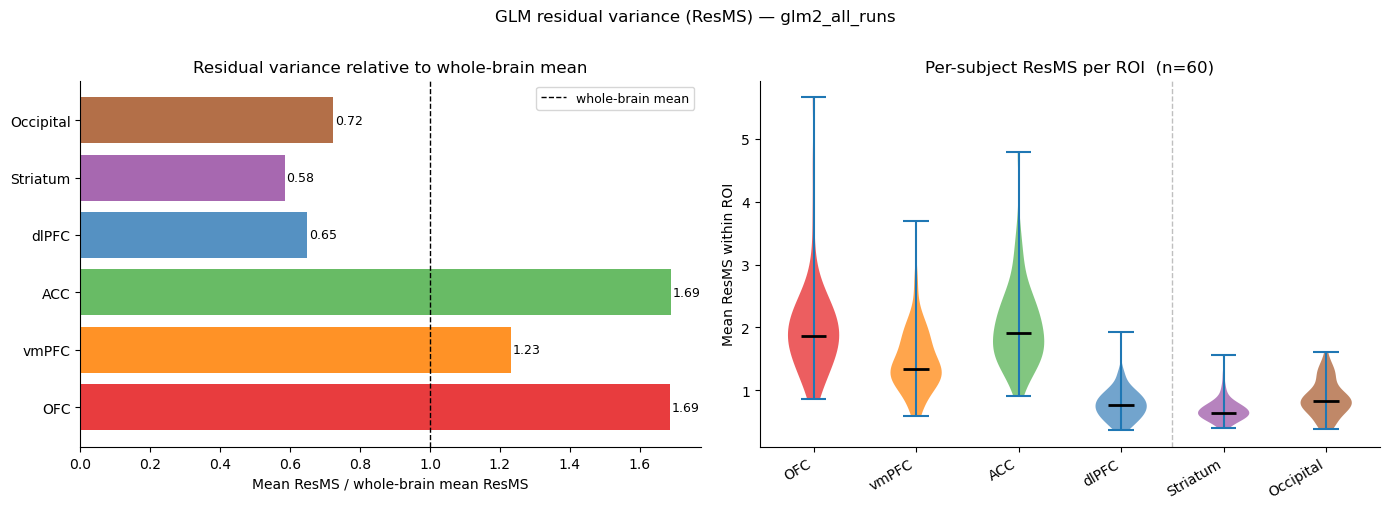

In [4]:
roi_order = PFC_ROIS + REF_ROIS
data_by_roi = [df_resms[df_resms['roi'] == r]['resms'].values for r in roi_order]
wb_means    = df_resms.groupby('subject')['wb_resms'].first().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: bar chart of group mean ResMS (normalized to whole-brain mean) ───
ratio_means = []
for roi in roi_order:
    vals = df_resms[df_resms['roi'] == roi]['resms'].values
    wb   = df_resms[df_resms['roi'] == roi]['wb_resms'].values
    ratio_means.append((vals / wb).mean())

ax = axes[0]
bars = ax.barh(roi_order, ratio_means,
               color=[colors[r] for r in roi_order], alpha=0.85)
ax.axvline(1.0, color='black', lw=1, ls='--', label='whole-brain mean')
ax.set_xlabel('Mean ResMS / whole-brain mean ResMS')
ax.set_title('Residual variance relative to whole-brain mean')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)
for bar, val in zip(bars, ratio_means):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

# ── Right: per-subject violin per ROI ─────────────────────────────────────
ax = axes[1]
parts = ax.violinplot(data_by_roi, positions=range(len(roi_order)),
                      showmedians=True, showextrema=True)
for pc, name in zip(parts['bodies'], roi_order):
    pc.set_facecolor(colors[name])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
ax.axvline(len(PFC_ROIS) - 0.5, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_xticks(range(len(roi_order)))
ax.set_xticklabels(roi_order, rotation=30, ha='right')
ax.set_ylabel('Mean ResMS within ROI')
ax.set_title(f'Per-subject ResMS per ROI  (n={n_subjects})')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('GLM residual variance (ResMS) — glm2_all_runs', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## Interpretation

| ROI | Mean ResMS | Interpretation |
|---|---|---|
| OFC | 2.01 | Highest residual variance — susceptibility dropout means the GLM is fitting noise |
| ACC | 2.03 | Equally elevated, unexpectedly — likely midline physiological noise (sagittal sinus) |
| vmPFC | 1.49 | Elevated relative to dlPFC and Striatum despite adequate tSNR; residual physiological noise near medial wall |
| Occipital | 0.87 | Near average |
| dlPFC | 0.78 | Good fit quality |
| Striatum | 0.69 | Lowest residual variance; strongest Q-value effects in the dataset |

**OFC and ACC** both have ~3× the residual variance of Striatum. OFC is expected
(signal dropout). ACC being equally poor was not — it does not suffer from the same
dropout, but proximity to the sagittal sinus likely introduces physiological noise
that the confound model does not fully capture.

**vmPFC** at 1.49 is substantially above dlPFC (0.78) and Striatum (0.69), even
though tSNR in vmPFC (74.4) was adequate. The GLM fit is noisier there than in
other PFC regions, possibly due to residual cardiac/respiratory pulsation near the
medial wall. This does not explain the null result — the beta analysis shows a weak
positive Q-value direction across subjects — but it means vmPFC carries more
unexplained variance per subject, which inflates within-subject error and reduces
sensitivity.

**dlPFC and Striatum** have the cleanest GLM fits, consistent with the strongest
and most reliable Q-value effects being found there.